In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  #so that we can interact with our graghts and see the values
from sklearn.model_selection import train_test_split  #to split data
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression   #The model we want to use
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display #so that we can print the table more beautiful.(DataFrame)
#Instead of "print" we now use "display"


sales_data = pd.read_csv(r"C:\Users\HP\Desktop\CODE ALPHA\archive 2\Advertising.csv")
display(sales_data)
display(sales_data.info())
display(sales_data.describe())
salesdrop = sales_data.dropna()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


None

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [109]:
import pandas as pd
# Make index start from 1
sales_data.index = range(1, len(sales_data) + 1) #WE ADDED +1 because the "len(sales_data) = 199" since it started at 0,1,...199
#drops a colomn "unnamed: 0"
sales_data.drop(columns=['Unnamed: 0'], inplace=True) #'Unnamed:0' is no more useful now
display(sales_data)


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


LOOKS BETTER NOW <br>

The table shows the amount spent on advertising across three media channels — TV, Radio, and Newspaper — and the<br> resulting Sales.<br>

The goal is to use these inputs to predict future sales based on how much is spent on each channel.

What we are going to do next <br>

1. Clean and prepare the data (check for missing values, normalize if needed).<br>

2. Split into training and testing sets. <br>

3. Train a regression model (e.g., LinearRegression from scikit-learn). <br>

4. Evaluate using RMSE or R² to see how well your model predicts sales. <br>

5. Interpret coefficients — they’ll tell you how much each advertising channel impacts sales. <br>

IN THIS CASE, OUR TARGET COLUMN IS THE "Sale"

In [110]:
sales_plot = px.histogram(sales_data, x = 'Sales', marginal = 'box', title = 'Sales', nbins= 40) #marginal puts that box ontop of the box on top of the plot to seen the pecentiles, median, etc.
sales_plot.update_layout(bargap=0.1) #only thing that can be used to put a gap)
sales_plot.show()

In [111]:
sales_plot = px.histogram(sales_data,x= 'TV' , y = 'Sales', marginal = 'box', title = 'Sales', nbins= 40) #marginal puts that box ontop of the box on top of the plot to seen the pecentiles, median, etc.
sales_plot.update_layout(bargap=0.1) #only thing that can be used to put a gap)
sales_plot.show()  #shows that cars of latest years cost more.

In [112]:
sales_data.Sales.corr(sales_data.TV)

np.float64(0.7822244248616066)

In [103]:
sales_plot = px.histogram(sales_data,x= 'Newspaper' , y = 'Sales', marginal = 'box', title = 'Sales', nbins= 40) #marginal puts that box ontop of the box on top of the plot to seen the pecentiles, median, etc.
sales_plot.update_layout(bargap=0.1)
sales_plot.show()

In [113]:
print('Newspaper =',sales_data.Sales.corr(sales_data.Newspaper))
print('Radio =', sales_data.Sales.corr(sales_data.Radio))
print('TV =', sales_data.Sales.corr(sales_data.TV))

display(sales_data)

Newspaper = 0.22829902637616534
Radio = 0.5762225745710552
TV = 0.7822244248616066


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


In [114]:
sales_plot = px.histogram(sales_data,x= 'Radio' , y = 'Sales', marginal = 'box', title = 'Selling Prices', nbins= 40) #marginal puts that box ontop of the box on top of the plot to seen the pecentiles, median, etc.
sales_plot.update_layout(bargap=0.1)
sales_plot.show()

We can see that Cars with lower mileage, has higher prices

In [116]:
display(sales_data)

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


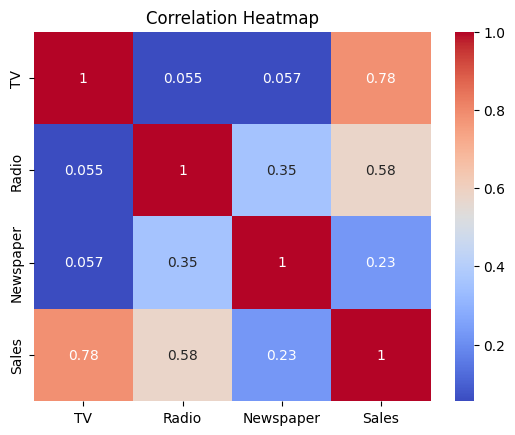

In [117]:
sns.heatmap(sales_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [46]:
px.scatter(sales_data, y = 'Sales', x = 'TV')

MODEL RECOMMENDATION
Begin with Linear Regression for baseline. Y = MX + C (equation of a straigh line)

Then test RANDOM FOREST and XGBOOST
they usually outperform linear models for car price prediction.

Evaluate using R², MAE, and RMSE to compare.

<2> If Nonlinear Patterns Exist (as your plot suggests) Note: ours is linear because only 'x' exists but no "x^2"
Try nonlinear or ensemble models that handle complex relationships:

Polynomial Regression (adds squared or cubic terms)

Random Forest Regressor — captures nonlinear interactions automatically.

XGBoost or LightGBM — excellent for tabular data with mixed feature types.

Gradient Boosting Regressor — balances bias and variance well.

So we will use

Selling Price = M x TV + c

In [118]:
def est_price (estprice, m, c ):   #def is used to define our model
    return m*estprice + c
m = 0.1
c = 5           #this is our first model formular (but it also what LinearRegression does)
estprice = sales_data['TV']       #we now use our desires column here
estimated_price = est_price(estprice, m,c)
display(estimated_price)


1      28.01
2       9.45
3       6.72
4      20.15
5      23.08
       ...  
196     8.82
197    14.42
198    22.70
199    33.36
200    28.21
Name: TV, Length: 200, dtype: float64

CheckPoint

In [119]:
display(sales_data['Sales']) #just to compare with the actual selling price

1      22.1
2      10.4
3       9.3
4      18.5
5      12.9
       ... 
196     7.6
197     9.7
198    12.8
199    25.5
200    13.4
Name: Sales, Length: 200, dtype: float64

In [120]:
px.scatter(sales_data, y = estimated_price, x = 'TV')  #they have a linear relationship.

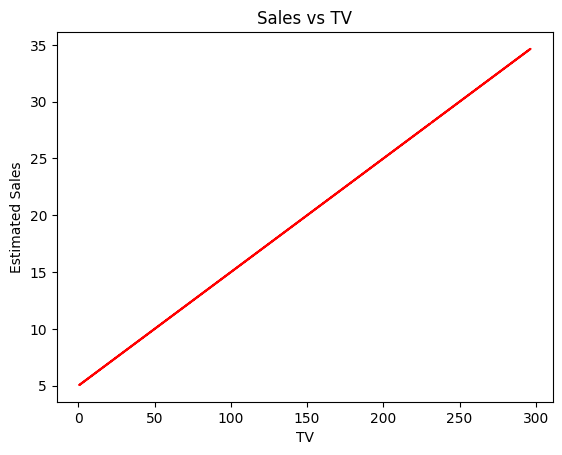

In [121]:
import matplotlib.pyplot as plt

# Assuming you already have these columns in your DataFrame
x = sales_data['TV']      # numeric column
y = estimated_price                  # predicted or target values

plt.plot(x, y, 'r-')
px.scatter(sales_data, y = 'Sales', x = 'TV')
plt.xlabel('TV')
plt.ylabel('Estimated Sales')
plt.title('Sales vs TV')
plt.show()


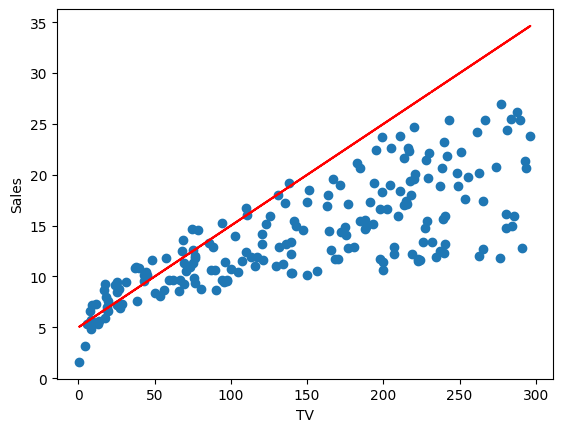

In [122]:
#target = pd.DataFrame(cars['Selling_Price']) #this is how to convert a single column to a dataframe and work with it
plt.plot(sales_data['TV'], estimated_price , 'r-')
plt.scatter(sales_data['TV'], sales_data['Sales'])
plt.xlabel('TV')
plt.ylabel('Sales')
plt.show()

LETS GET A FUNCTION THAT WE CAN USE TO TRY DIFFERENT VALUES OF 'M' AND 'C'

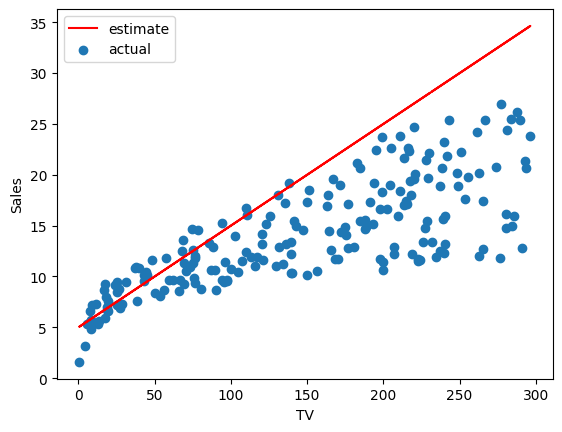

,Predicted,Actual
1,28.01,22.1
2,9.45,10.4
3,6.72,9.3
4,20.15,18.5
5,23.08,12.9
...,...,...
196,8.82,7.6
197,14.42,9.7
198,22.70,12.8
199,33.36,25.5


In [123]:
estprice = sales_data['TV']

#you can use this function to manually try and fit the line of regression

def try_price(m, c):
    def est_price(estprice, m, c):
        return m * estprice + c

    estimated_price = est_price(estprice, m, c)

    plt.plot(sales_data['TV'], estimated_price, 'r-')
    plt.scatter(sales_data['TV'], sales_data['Sales'])
    plt.xlabel('TV')
    plt.ylabel('Sales')
    plt.legend(['estimate', 'actual'])
    plt.show()
    return estimated_price
target = sales_data['Sales']
comparison = try_price(0.1,5)   #change the values of try(2,1) to see how close you get to the actual price
forecast = pd.DataFrame({'Predicted': comparison, 'Actual': target}) #The fix is to build the DataFrame from a dict mapping column names to your two series.
display(forecast)


CALCULATE LOSS/COST FUNCTIONS

We will now compare our estimate with the actual selling price using the Root Mean Square Error (RMSE)

RMSE (Root Mean Square Error) is used to measure how far off your model's predictions are from the actual values.
Absolut values '|predicted - actual|' can be takes too.
NOTE that Outliers have a bigger effect on Square method more than Abosolute Methods because if the gap is too much, the square will also be bigger. However, absolute values just ignores the -ve sign.

E.g.  (4- 9) gives -5. Which means the Square is 25. But Abosolute value just leave it at 5

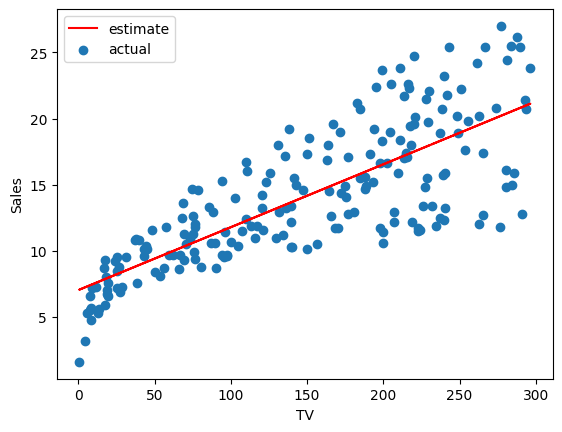

np.float64(3.242322148654689)

In [129]:
target = sales_data['Sales']
predictions = try_price(0.04753664,7.032593549127695)   #from the 'rmse result' (1,2) is better than (2,1)
def rmse (target, predictions):#dont forget your ':'
      return np.sqrt(np.mean(np.square(target - predictions)))


rmse (target, predictions)

your `m` value can be very small to compensate for very large values of x. Here's why:

**Your formula is:**
```
estimated_price = m * estprice + c
```

If `estprice` is `1000+` and you want output between `3-20`, then `m` needs to be tiny to scale it down, for example:

```
m = 0.001, c = 2
→ 0.001 * 1000 + 2 = 3      ✅
→ 0.001 * 5000 + 2 = 7      ✅
→ 0.001 * 18000 + 2 = 20    ✅
```

**The real problem though** is that finding the right `m` by trial and error becomes very hard because:
- A tiny change in `m` (e.g. `0.001` → `0.002`) causes a huge swing in predictions
- It makes tuning very frustrating

**The proper fix is to scale your feature first:**

```python
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
estprice = scaler.fit_transform(cars[['Car_depre_price']])  # squishes values to 0-1 range
```

Now your feature is between `0` and `1`, so your `m` and `c` values become much more intuitive to tune and your predictions in the `3-20` range are easier to dial in.

**In short:**
- Mathematically it still works ✅
- But practically, scaling your feature first makes life much easier ✅

In [124]:
model = LinearRegression()   #this is where you define what kind of model you want and what the relationship is

In [125]:
fstinput = sales_data[['TV']]  #cars[] will give me 1D, remember that 'mosel.fit' need 2D so use cars[[]]
target = sales_data['Sales'] #this one can be left as 1D
display(fstinput.shape, target.shape)


(200, 1)

(200,)

In [ ]:
x = sales_data[['TV']]   # independent variables
y = sales_data['Sales']                        # target variable
model = LinearRegression()
model.fit(x, y)
# Predict using your trained model
prediction = model.predict(x)   #now testing with the data i split to test only

# Combine actual and predicted into a DataFrame
comparison = pd.DataFrame({
    "Actual Sales": y,    #convert them to Dictionaries a basic way to generating a DataFrame
    "Predicted Sales": prediction     #Our Model Predictions
})

display(comparison)


,Actual Sales,Predicted Sales
1,22.1,17.970775
2,10.4,9.147974
3,9.3,7.850224
4,18.5,14.234395
5,12.9,15.627218
...,...,...
196,7.6,8.848493
197,9.7,11.510545
198,12.8,15.446579
199,25.5,20.513985


In [128]:
print('coeff:', model.coef_)
print('intercept:', model.intercept_)

coeff: [0.04753664]
intercept: 7.032593549127695


Let now try it back in our previous function


Now we will split our data, some for training it to know how good it is and some for testing it before deploying

In [130]:
from sklearn.model_selection import train_test_split

# Select multiple columns as features
x = sales_data[['TV','Radio', 'Newspaper']]   # independent variables
y = sales_data['Sales']                        # target variable

# Split into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


This called tuple unpacking. It’s Python’s way of assigning multiple outputs from a function in one clean line. <br>
because train_test_split runs and returns a tuple with four elements: <br>

Element 0 → training features (X_train) <br>

Element 1 → testing features (X_test)<br>

Element 2 → training target (y_train)<br>

Element 3 → testing target (y_test)<br>

(X_train_array, X_test_array, y_train_array, y_test_array)

Tuple unpacking happens:
Python sees four variables on the left side, separated by commas.
It matches them in order:

X_train = tuple[0]

X_test = tuple[1]

y_train = tuple[2]

y_test = tuple[3]

So the number of returned elements depends on how many arrays you feed in. Each one gets split into a train part and a test part


train_test_split() divides your data into training and testing subsets. <br>

fstinput → your features (independent variables). <br>

target → your labels (dependent variable). <br>

test_size=0.2 → 20 % of the data goes to testing, 80 % to training. <br>

random_state=42 → ensures the split is reproducible every time you run it. <br>

In [131]:
model = LinearRegression()
model.fit(x_train, y_train)

#we could have also said LinearRegression.fit(), but we already assinged model= LinearRegression()
#'fit' here will help us determine the best slope 'm' and y-intercept'c' of out regression line.
#it will continue to do all those (2,1) changing and calculate RMSE and give me the result

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


The .fit() method is the moment your model “learns” from the data.

So, now we can predict the prices for any car if we know its

THIS IS BASICALLY THE PRICTION USER INTERFACE <br>
Because it allows you predict the price of any car, given the "year","mileage" and "the type of seller (dealer/owner)"

In [132]:
print(x_test.shape)
print(y_test.shape)


(40, 3)
(40,)


scikit‑learn’s `LinearRegression()` implements the classic linear model, which in its simplest form is the familiar equation:

\[
y = m x + c
\]

where:
- \(y\) = predicted output (target variable)  
- \(x\) = input feature (independent variable)  
- \(m\) = slope (coefficient)  
- \(c\) = intercept (bias term)

---

### But here’s the important detail:
- If you have **one feature**, it’s literally \(y = m x + c\).  
- If you have **multiple features**, it generalizes to:

\[
y = x0+ Kx_1 + Kx_2 + ... + Kx_n
\]

where \(x0) is the intercept and each \(\Xn\) is a coefficient for feature \(K).


👉 In practice, after fitting your model with `model.fit(X, y)`, you can inspect the learned parameters:

```python
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
```

That will show you the actual \(c\) and \(m\) values (or multiple slopes if you have more than one feature).

---

Would you like me to show you how to **interpret those coefficients** in the context of your car dataset — e.g., how much the price changes per unit increase in mileage or seller type?

In [133]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


# Predict using your trained model
prediction = model.predict(x_test)   #now testing with the data i split to test only

# Combine actual and predicted into a DataFrame
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,    #convert them to Dictionaries a basic way to generating a DataFrame
    "Predicted Sales": prediction     #Our Model Predictions
})

display(comparison)  #expect 40 rows, cus i rained it with 40 rows

def rmse (target, predictions):#dont forget your ':'
      return np.sqrt(np.mean(np.square(target - predictions)))




print('RMSE = ', rmse(y_test, prediction))
Coefficient_of_determination = r2_score(y_test, prediction)

print("Coefficient_of_determination =", Coefficient_of_determination)



,Actual Sales,Predicted Sales
0,16.9,16.408024
1,22.4,20.889882
2,21.4,21.553843
3,7.3,10.608503
4,24.7,22.112373
5,12.6,13.105592
6,22.3,21.057192
7,8.4,7.461010
8,11.5,13.606346
9,14.9,15.155070


RMSE =  1.78159966153345
Coefficient_of_determination = 0.899438024100912


since we split to take 40 data from our original data set.

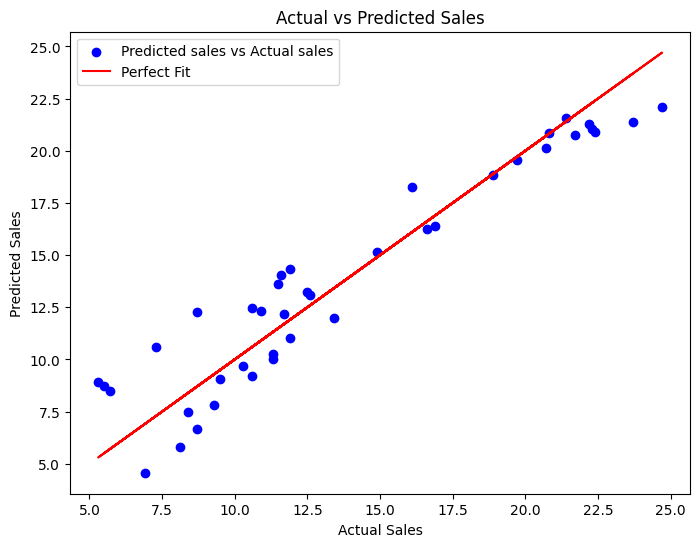

In [94]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, prediction, color='blue', label='Predicted sales vs Actual sales')
plt.plot(y_test, y_test, 'r-', label='Perfect Fit')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.legend()
plt.show()


In [134]:
# Get the indices of the test set
test_indices = y_test.index

# Show the actual rows from the original DataFrame
sales_data.loc[test_indices] #and how the test data was split. 

,TV,Radio,Newspaper,Sales
96,163.3,31.6,52.9,16.9
16,195.4,47.7,52.9,22.4
31,292.9,28.3,43.2,21.4
159,11.7,36.9,45.2,7.3
129,220.3,49.0,3.2,24.7
116,75.1,35.0,52.7,12.6
70,216.8,43.9,27.2,22.3
171,50.0,11.6,18.4,8.4
175,222.4,3.4,13.1,11.5
46,175.1,22.5,31.5,14.9


Because your model uses many features at once, you can’t reduce it to a single straight line in 2D. <br> 
Instead, the Actual vs Predicted plot gives you a direct, intuitive view of how well your model generalizes: <br>

It shows the overall accuracy of predictions. <br>

It highlights outliers where the model struggles. <br>

It visually confirms whether your model is biased (e.g., consistently under‑ or over‑predicting). <br>

👉 In a simple linear regression (one feature → one target), the relationship is a straight line in 2D. <br>
👉 In a multiple linear regression (many features → one target), the relationship is a plane (or hyperplane) <br> 
    in higher dimensions. That plane can’t be shown as a single straight line in 2D because each prediction depends <br> on all the features at once.

That’s why your plots look messy when you try to force the multivariate predictions into a single x‑axis vs y‑axis <br> 
scatter — the model isn’t just fitting one variable, it’s fitting the combination.

What the plot communicates <br>
Blue dots (scatter) → Each dot is one test sample.<br>

1. X‑axis = the actual sales values from your DataFrame (y_test).<br>

2. Y‑axis = the predicted sales values from your model (prediction).<br>

3. So every dot shows: “This is what the data really said vs. what my model predicted.”<br>

4. Red dashed line (perfect fit reference) → This is the line where predicted = actual.<br>


If your model were flawless, all blue dots would sit exactly on this line.<br>
The closer your dots are to this line, the better your model is performing.<br>
Distance from the line → The vertical distance between a dot and the red line is the error (residual) for that prediction.<br>
Small distance = accurate prediction.<br>
Large distance = poor prediction.<br>

USE INTERFACE

In [136]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Collect user input
TV_price = float(input("Enter the amount paid for TV subscription: "))
Radio_price = float(input("Enter the amount paid for Radio subscription: "))
Newspaper_price = float(input("Enter the amount paid for Newspaper subscription: "))

inputsdata = np.array([[TV_price,Radio_price,Newspaper_price]])

# Predict using your trained model
prediction = model.predict(inputsdata)
print("Predicted value:", prediction)


Predicted value: [13.47419743]


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [137]:
model.intercept_

np.float64(2.979067338122629)

In [ ]:
print("Coefficient:", model.coef_) #this will also give you the weights used for each feature [TV, Radio, Newspaper]
print("Intercept:", model.intercept_)

Coefficient: [0.04472952 0.18919505 0.00276111]
Intercept: 2.979067338122629


But here’s the important detail:
If you have one feature, it’s literally
𝑦 = 𝑚𝑥 + 𝑐 . <br>
If you have multiple features, it generalizes to:<br>

𝑦 = c + 𝛽b + 𝛽c + ⋯ + 𝛽𝑛
where
c is the intercept and each

𝛽
 is a coefficient for feature
n
So in your car price model, if you’re using two features (like car_usage and seller_type), the formula looks like:

Price = c + 𝛽⋅car_usage + 𝛽⋅seller_type

SUMMARY <BR>
Training = model.fit(X, y) → learns from your dataset.   X = cars[['car_useage', 'Fuel_Type']]<br>

Prediction = model.predict(new_data) → uses what it learned to estimate new outcomes.